# AI Agent Performance Monitoring System
### Scoring Pipeline & Benchmark Analysis

This notebook loads the simulated AI agent conversation dataset (10,000 records / 12 agents)
and computes four business-oriented performance scores for each agent:

- **Agent Health Score** – overall performance indicator
- **Efficiency Score** – cost vs value
- **Customer Experience Score** – satisfaction & escalation quality
- **Reliability Score** – consistency & resolution quality

It then produces Agent Benchmark Rankings with a performance status and recommended action for each agent.

## 1. Load & Inspect Data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/ai_agent_performance_dataset.csv")
print(f"Rows: {len(df)}  |  Agents: {df['agent_name'].nunique()}  |  Domains: {df['agent_domain'].nunique()}")
df.head()

Rows: 10000  |  Agents: 12  |  Domains: 6


,conversation_id,agent_name,agent_domain,department_industry,query_type,conversation_date,resolution_time_sec,resolution_status,escalated,customer_satisfaction,tokens_used,cost_per_conversation_usd,response_consistency_score,repetitive_response_flag
0,CONV005260,SupportBot-v4,Customer Support,Manufacturing,Refund Request,2025-01-01 00:10:00,128.0,Resolved,No,4.7,700,0.0467,93.6,No
1,CONV005180,KnowledgeFinder-Lite,Internal Knowledge Search,Banking,Document Search,2025-01-01 00:12:00,119.7,Resolved,No,3.3,264,0.0240,84.3,No
2,CONV007485,KnowledgeFinder-Lite,Internal Knowledge Search,Retail,Policy Lookup,2025-01-01 00:21:00,149.0,Resolved,No,3.0,231,0.0223,70.9,No
3,CONV009292,SupportBot-v3,Customer Support,Telecom,Refund Request,2025-01-01 00:35:00,143.0,Resolved,No,4.0,957,0.0552,84.2,No
4,CONV002315,SupportBot-v3,Customer Support,Banking,Refund Request,2025-01-01 00:39:00,69.9,Resolved,No,4.2,256,0.0287,85.8,No


In [2]:
df.info()
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   conversation_id             10000 non-null  str    
 1   agent_name                  10000 non-null  str    
 2   agent_domain                10000 non-null  str    
 3   department_industry         10000 non-null  str    
 4   query_type                  10000 non-null  str    
 5   conversation_date           10000 non-null  str    
 6   resolution_time_sec         10000 non-null  float64
 7   resolution_status           10000 non-null  str    
 8   escalated                   10000 non-null  str    
 9   customer_satisfaction       10000 non-null  float64
 10  tokens_used                 10000 non-null  int64  
 11  cost_per_conversation_usd   10000 non-null  float64
 12  response_consistency_score  10000 non-null  float64
 13  repetitive_response_flag    10000 non-null 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
conversation_id,10000,10000,CONV005260,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agent_name,10000,12,SupportBot-v4,1189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agent_domain,10000,6,Customer Support,3158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department_industry,10000,8,Telecom,1310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query_type,10000,28,General Inquiry,653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conversation_date,10000,9900,2025-03-21 13:41:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolution_time_sec,10000.0,NaN,NaN,NaN,98.19501,70.477317,15.0,46.3,81.9,133.0,597.6
resolution_status,10000,3,Resolved,8560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
escalated,10000,2,No,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_satisfaction,10000.0,NaN,NaN,NaN,4.02785,0.691248,1.2,3.6,4.1,4.6,5.0


## 2. Aggregate Per-Agent Metrics

In [3]:
def pct_yes(series):
    return (series == "Yes").mean() * 100

agent_agg = df.groupby("agent_name").agg(
    agent_domain=("agent_domain", "first"),
    total_conversations=("conversation_id", "count"),
    avg_resolution_time_sec=("resolution_time_sec", "mean"),
    resolution_rate=("resolution_status", lambda s: (s == "Resolved").mean() * 100),
    escalation_rate=("escalated", pct_yes),
    avg_satisfaction=("customer_satisfaction", "mean"),
    avg_tokens=("tokens_used", "mean"),
    avg_cost_per_conv=("cost_per_conversation_usd", "mean"),
    avg_consistency=("response_consistency_score", "mean"),
    repetitive_rate=("repetitive_response_flag", pct_yes),
).reset_index()

agent_agg

,agent_name,agent_domain,total_conversations,avg_resolution_time_sec,resolution_rate,escalation_rate,avg_satisfaction,avg_tokens,avg_cost_per_conv,avg_consistency,repetitive_rate
0,HR-FAQ-Agent,HR Queries,798,101.110777,84.085213,9.649123,3.900125,483.184211,0.034246,86.250752,6.766917
1,HRQueryBot,HR Queries,799,95.299374,85.732165,7.634543,4.088360,407.770964,0.029877,88.140426,5.256571
2,IT-Legacy-Bot,IT Helpdesk,509,129.457957,76.817289,16.895874,2.998625,597.717092,0.044037,78.991159,14.734774
3,ITHelpDesk-AI,IT Helpdesk,508,111.455906,78.346457,15.157480,3.426181,550.458661,0.040726,82.346850,11.811024
4,KnowledgeFinder-Lite,Internal Knowledge Search,726,115.914876,84.848485,9.090909,3.607713,472.723140,0.034968,83.941185,11.157025
5,KnowledgeFinder-X,Internal Knowledge Search,877,83.016306,91.220068,3.534778,4.457583,436.059293,0.031741,90.850513,2.964652
6,OmniAssist-2,Customer Support,1173,91.886786,87.723785,5.967604,4.238875,454.714408,0.032787,88.763512,5.115090
7,SalesAssist-Lite,Sales Assistance,696,119.404167,79.454023,14.224138,3.223420,505.489943,0.036214,80.907040,14.080460
8,SalesAssist-Pro,Sales Assistance,1033,90.457406,87.512101,5.711520,4.337076,446.838335,0.032828,89.735140,3.678606
9,SchedulerBot,Appointment Scheduling,896,88.188281,88.616071,4.687500,4.522879,394.050223,0.028946,91.320982,2.566964


## 3. Scoring Methodology

All raw metrics are min-max normalized to a 0-100 scale so they can be combined fairly, regardless of original units (seconds, dollars, percentages).

| Score | Formula (weights) |
|---|---|
| **Efficiency Score** | Cost (45%) + Tokens (30%) + Resolution Rate (25%) — cost & tokens inverted (lower = better) |
| **Customer Experience Score** | Satisfaction (55%) + Escalation (30%, inverted) + Repetition (15%, inverted) |
| **Reliability Score** | Consistency (45%) + Resolution Rate (30%) + Escalation (25%, inverted) |
| **Agent Health Score** | Efficiency (30%) + Customer Experience (40%) + Reliability (30%) |

Customer Experience is weighted highest in the Health Score because customer-facing quality is the leadership team's top strategic concern (see Task brief: satisfaction & resolution rate).

In [4]:
def normalize(series, invert=False):
    mn, mx = series.min(), series.max()
    if mx == mn:
        scaled = pd.Series([50] * len(series), index=series.index)
    else:
        scaled = (series - mn) / (mx - mn) * 100
    return 100 - scaled if invert else scaled

a = agent_agg.copy()

# Efficiency
cost_score = normalize(a["avg_cost_per_conv"], invert=True)
token_score = normalize(a["avg_tokens"], invert=True)
resolution_score_eff = normalize(a["resolution_rate"])
a["efficiency_score"] = (cost_score*0.45 + token_score*0.30 + resolution_score_eff*0.25).round(1)

# Customer Experience
satisfaction_score = normalize(a["avg_satisfaction"])
escalation_score = normalize(a["escalation_rate"], invert=True)
repetition_score = normalize(a["repetitive_rate"], invert=True)
a["customer_experience_score"] = (satisfaction_score*0.55 + escalation_score*0.30 + repetition_score*0.15).round(1)

# Reliability
consistency_score = normalize(a["avg_consistency"])
resolution_score_rel = normalize(a["resolution_rate"])
escalation_score_rel = normalize(a["escalation_rate"], invert=True)
a["reliability_score"] = (consistency_score*0.45 + resolution_score_rel*0.30 + escalation_score_rel*0.25).round(1)

# Agent Health Score
a["agent_health_score"] = (a["efficiency_score"]*0.30 + a["customer_experience_score"]*0.40 + a["reliability_score"]*0.30).round(1)

a[["agent_name","efficiency_score","customer_experience_score","reliability_score","agent_health_score"]]

,agent_name,efficiency_score,customer_experience_score,reliability_score,agent_health_score
0,HR-FAQ-Agent,58.7,57.0,53.7,56.5
1,HRQueryBot,85.7,69.8,67.4,73.9
2,IT-Legacy-Bot,0.0,0.0,0.0,0.0
3,ITHelpDesk-AI,19.5,22.2,18.0,20.1
4,KnowledgeFinder-Lite,59.4,42.9,48.4,49.5
5,KnowledgeFinder-X,85.5,94.5,95.9,92.2
6,OmniAssist-2,73.5,78.9,76.8,76.6
7,SalesAssist-Lite,41.5,14.5,17.1,23.4
8,SalesAssist-Pro,74.2,84.6,80.2,80.2
9,SchedulerBot,95.5,94.7,89.9,93.5


## 4. Performance Status & Recommended Actions

In [5]:
def performance_status(score):
    if score >= 85: return "Top Performer"
    elif score >= 70: return "Solid Performer"
    elif score >= 55: return "Needs Improvement"
    else: return "Underperforming"

def recommended_action(row):
    scores = {
        "efficiency_score": row["efficiency_score"],
        "customer_experience_score": row["customer_experience_score"],
        "reliability_score": row["reliability_score"],
    }
    weakest = min(scores, key=scores.get)
    if row["performance_status"] == "Top Performer":
        return "Expand deployment across more departments; use as training benchmark."
    if weakest == "efficiency_score":
        return "Optimize prompt length / token usage to reduce cost per conversation."
    if weakest == "customer_experience_score":
        return "Retrain on domain-specific queries; review escalation triggers."
    return "Improve response consistency via workflow redesign and QA sampling."

a["performance_status"] = a["agent_health_score"].apply(performance_status)
a["recommended_action"] = a.apply(recommended_action, axis=1)
a["rank"] = a["agent_health_score"].rank(ascending=False, method="min").astype(int)
a = a.sort_values("rank")
a[["rank","agent_name","agent_health_score","performance_status","recommended_action"]]

,rank,agent_name,agent_health_score,performance_status,recommended_action
11,1,SupportBot-v4,96.6,Top Performer,Expand deployment across more departments; use...
9,2,SchedulerBot,93.5,Top Performer,Expand deployment across more departments; use...
5,3,KnowledgeFinder-X,92.2,Top Performer,Expand deployment across more departments; use...
8,4,SalesAssist-Pro,80.2,Solid Performer,Optimize prompt length / token usage to reduce...
6,5,OmniAssist-2,76.6,Solid Performer,Optimize prompt length / token usage to reduce...
1,6,HRQueryBot,73.9,Solid Performer,Improve response consistency via workflow rede...
0,7,HR-FAQ-Agent,56.5,Needs Improvement,Improve response consistency via workflow rede...
4,8,KnowledgeFinder-Lite,49.5,Underperforming,Retrain on domain-specific queries; review esc...
10,9,SupportBot-v3,37.2,Underperforming,Optimize prompt length / token usage to reduce...
7,10,SalesAssist-Lite,23.4,Underperforming,Retrain on domain-specific queries; review esc...


## 5. Agent Benchmark Rankings (Final Output)

In [6]:
for col in ["avg_resolution_time_sec","resolution_rate","escalation_rate","avg_satisfaction",
            "avg_tokens","avg_cost_per_conv","avg_consistency","repetitive_rate"]:
    a[col] = a[col].round(2)

output_cols = ["rank","agent_name","agent_domain","total_conversations","agent_health_score",
               "efficiency_score","customer_experience_score","reliability_score","avg_satisfaction",
               "resolution_rate","escalation_rate","avg_cost_per_conv","avg_tokens","avg_consistency",
               "repetitive_rate","performance_status","recommended_action"]

a[output_cols].to_csv("../reports/agent_benchmark_report.csv", index=False)
a[output_cols]

,rank,agent_name,agent_domain,total_conversations,agent_health_score,efficiency_score,customer_experience_score,reliability_score,avg_satisfaction,resolution_rate,escalation_rate,avg_cost_per_conv,avg_tokens,avg_consistency,repetitive_rate,performance_status,recommended_action
11,1,SupportBot-v4,Customer Support,1189,96.6,93.0,99.6,96.3,4.59,89.57,3.70,0.03,404.35,92.05,2.27,Top Performer,Expand deployment across more departments; use...
9,2,SchedulerBot,Appointment Scheduling,896,93.5,95.5,94.7,89.9,4.52,88.62,4.69,0.03,394.05,91.32,2.57,Top Performer,Expand deployment across more departments; use...
5,3,KnowledgeFinder-X,Internal Knowledge Search,877,92.2,85.5,94.5,95.9,4.46,91.22,3.53,0.03,436.06,90.85,2.96,Top Performer,Expand deployment across more departments; use...
8,4,SalesAssist-Pro,Sales Assistance,1033,80.2,74.2,84.6,80.2,4.34,87.51,5.71,0.03,446.84,89.74,3.68,Solid Performer,Optimize prompt length / token usage to reduce...
6,5,OmniAssist-2,Customer Support,1173,76.6,73.5,78.9,76.8,4.24,87.72,5.97,0.03,454.71,88.76,5.12,Solid Performer,Optimize prompt length / token usage to reduce...
1,6,HRQueryBot,HR Queries,799,73.9,85.7,69.8,67.4,4.09,85.73,7.63,0.03,407.77,88.14,5.26,Solid Performer,Improve response consistency via workflow rede...
0,7,HR-FAQ-Agent,HR Queries,798,56.5,58.7,57.0,53.7,3.90,84.09,9.65,0.03,483.18,86.25,6.77,Needs Improvement,Improve response consistency via workflow rede...
4,8,KnowledgeFinder-Lite,Internal Knowledge Search,726,49.5,59.4,42.9,48.4,3.61,84.85,9.09,0.03,472.72,83.94,11.16,Underperforming,Retrain on domain-specific queries; review esc...
10,9,SupportBot-v3,Customer Support,796,37.2,33.9,37.5,40.0,3.64,82.16,11.56,0.04,532.67,84.46,11.93,Underperforming,Optimize prompt length / token usage to reduce...
7,10,SalesAssist-Lite,Sales Assistance,696,23.4,41.5,14.5,17.1,3.22,79.45,14.22,0.04,505.49,80.91,14.08,Underperforming,Retrain on domain-specific queries; review esc...


## 6. Quick Visualization: Health Score by Agent

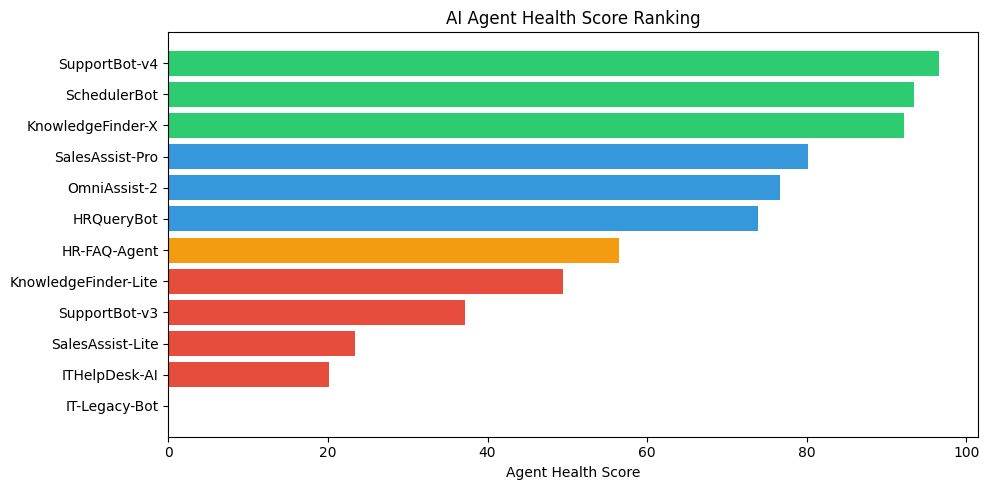

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
colors = ["#2ecc71" if s=="Top Performer" else "#3498db" if s=="Solid Performer"
          else "#f39c12" if s=="Needs Improvement" else "#e74c3c" for s in a["performance_status"]]
plt.barh(a["agent_name"], a["agent_health_score"], color=colors)
plt.xlabel("Agent Health Score")
plt.title("AI Agent Health Score Ranking")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/health_score_chart.png", dpi=120)
plt.show()

## 7. Key Insights

- **Top performers** (SupportBot-v4, SchedulerBot, KnowledgeFinder-X) combine low cost, high satisfaction, and low escalation — ideal candidates for wider rollout.
- **Underperformers** (IT-Legacy-Bot, ITHelpDesk-AI, SalesAssist-Lite) show high escalation and token cost — these need retraining or replacement before further deployment.
- IT Helpdesk domain agents consistently score lower — indicates a **domain-level gap**, not just an agent-level one, worth investigating in workflow design.
- Full breakdown and recommended actions are saved in `reports/agent_benchmark_report.csv` and visualized live in the Streamlit dashboard (`app/dashboard.py`).